# Multiple Linear Regression - Toyota Corolla Dataset

## Objective
To predict the Price of Toyota Corolla cars using Multiple Linear Regression.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Train Test Split
from sklearn.model_selection import train_test_split

# Linear Regression
from sklearn.linear_model import LinearRegression

# Ridge and Lasso Regresion
from sklearn.linear_model import Ridge, Lasso

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ridge and Lasso
from sklearn.linear_model import Ridge, Lasso

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load dataset

df = pd.read_csv("ToyotaCorolla - MLR.csv")

# Display first 5 rows
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [3]:
# Display dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [4]:
# Check missing values

df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

# Exploratory Data Analysis (EDA)

In [5]:
# Statistical summary

df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [6]:
# Check duplicate rows

df.duplicated().sum()

np.int64(1)

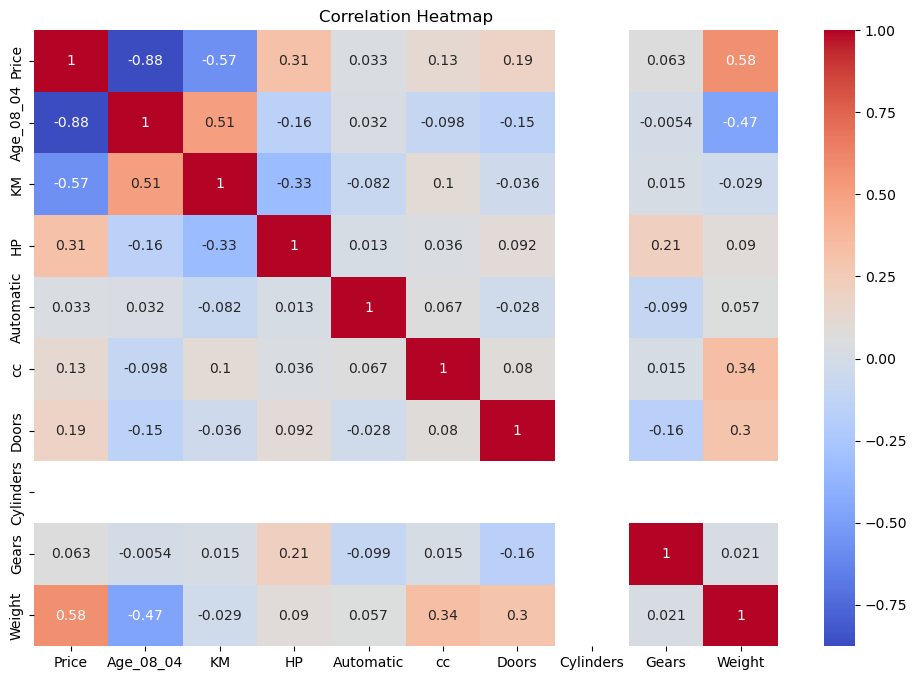

In [7]:
# Correlation heatmap

plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

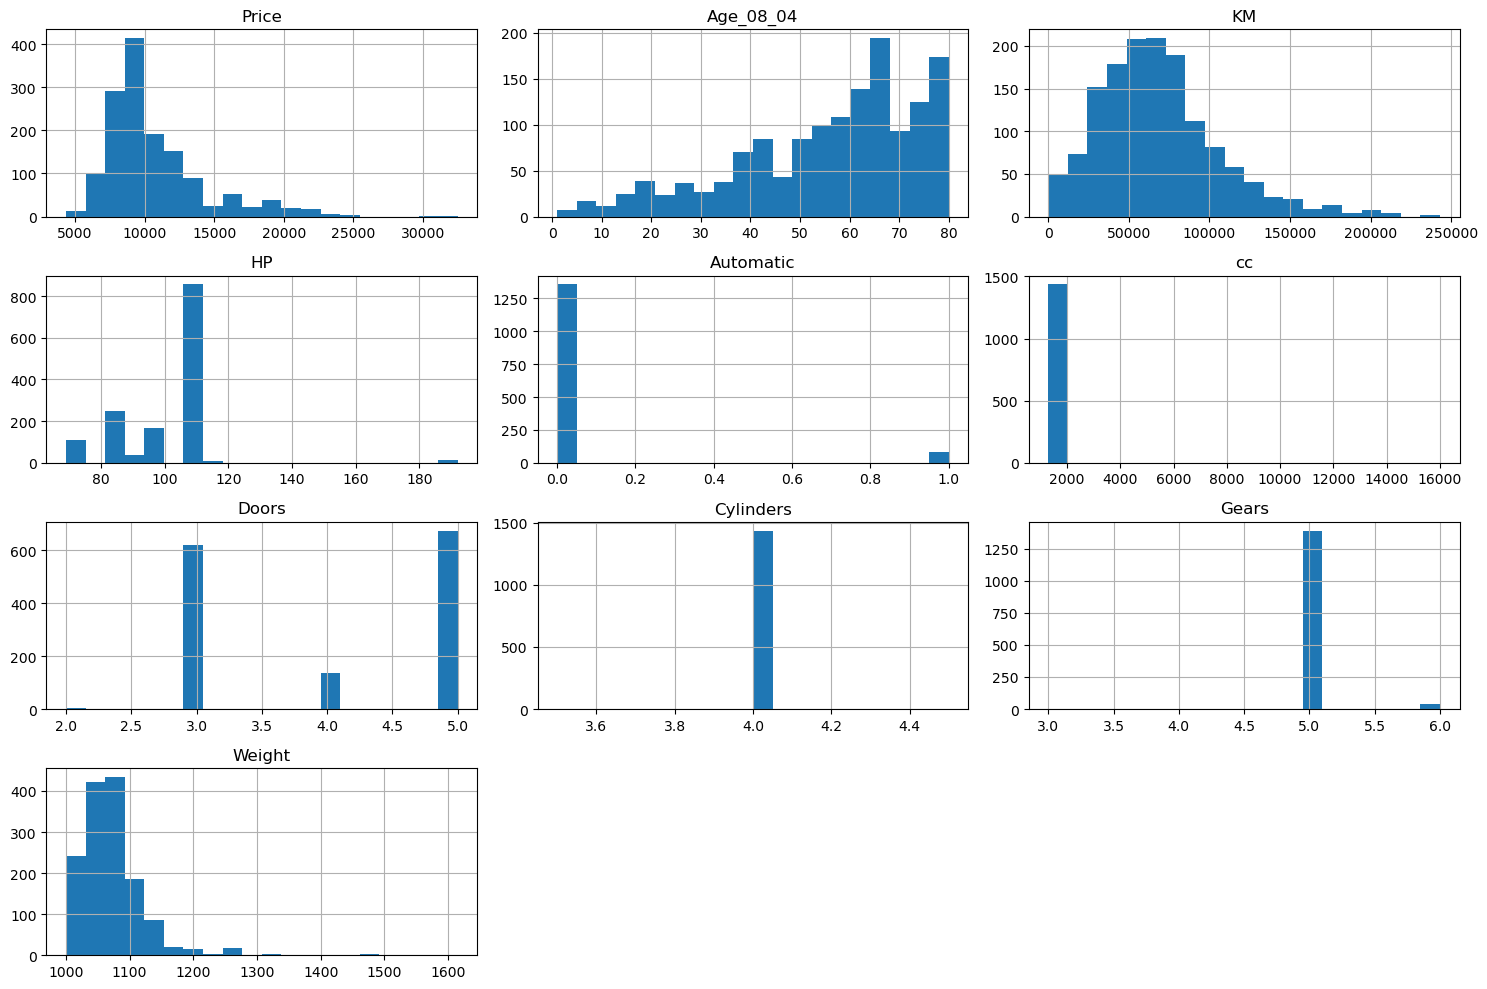

In [8]:
# Plot histograms for numerical columns

df.hist(figsize=(15,10), bins=20)

plt.tight_layout()

plt.show()

In [9]:
print(df.columns.tolist())

['Price', 'Age_08_04', 'KM', 'Fuel_Type', 'HP', 'Automatic', 'cc', 'Doors', 'Cylinders', 'Gears', 'Weight']


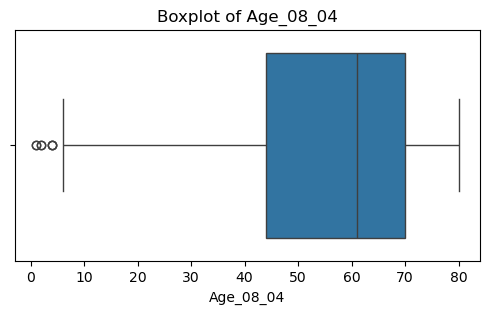

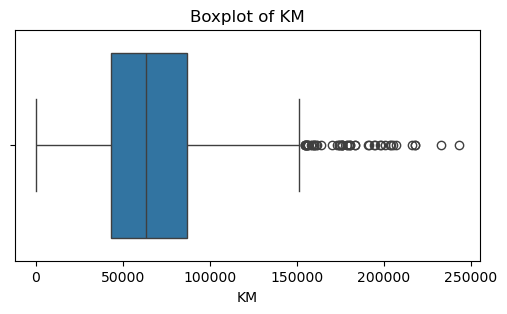

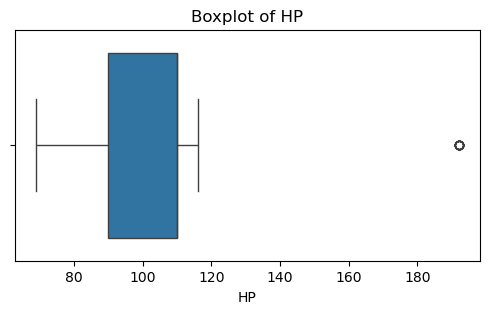

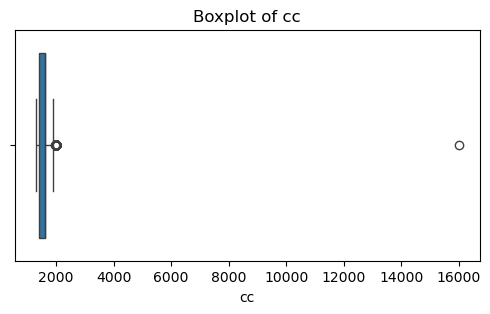

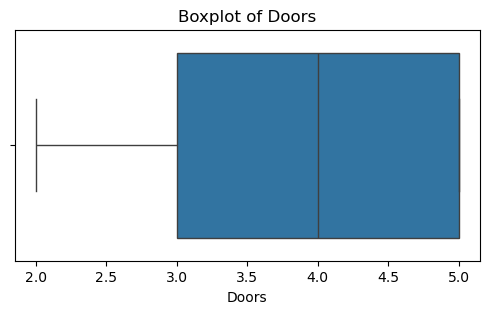

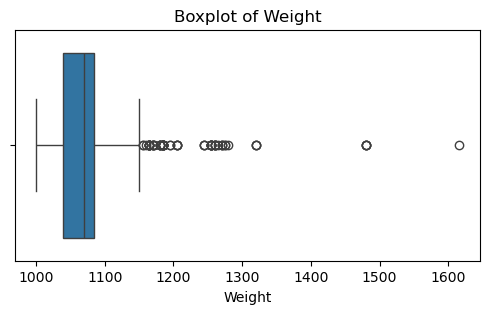

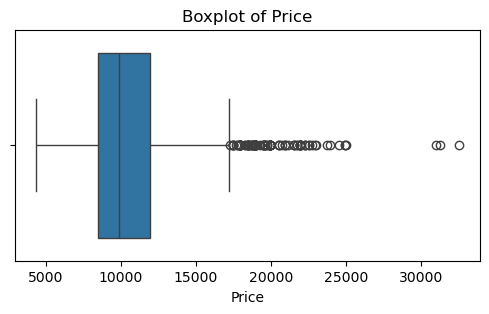

In [10]:
# Boxplots to detect outliers

numerical_cols = ['Age_08_04',
                  'KM',
                  'HP',
                  'cc',
                  'Doors',
                  'Weight',
                  'Price']

for col in numerical_cols:
    
    plt.figure(figsize=(6,3))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

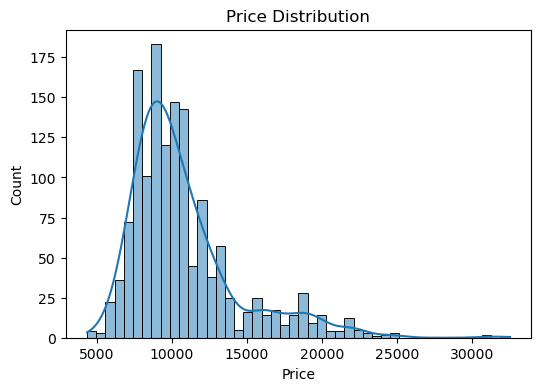

In [11]:
# Price Distribution

plt.figure(figsize=(6,4))

sns.histplot(df['Price'], kde=True)

plt.title("Price Distribution")
plt.show()

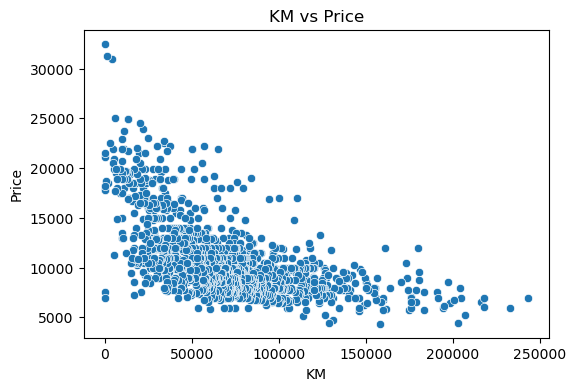

In [12]:
# Scatter plot between KM and Price

plt.figure(figsize=(6,4))

sns.scatterplot(x=df['KM'], y=df['Price'])

plt.title("KM vs Price")
plt.show()

# Data Preprocessing
- Convert categorical data into numerical form
- Define independent and dependent variables

In [13]:
# Convert categorical columns

df = pd.get_dummies(df, drop_first=True)

# Drop highly correlated column to reduce multicollinearity

if "Manufacturing_Year" in df.columns:
    df.drop("Manufacturing_Year", axis=1, inplace=True)

# Independent and dependent variables

X = df.drop("Price", axis=1)
y = df["Price"]

print("X Shape :", X.shape)
print("y Shape :", y.shape)

X Shape : (1436, 11)
y Shape : (1436,)


# Multicollinearity Check using VIF

In [14]:
# Calculate VIF values

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Convert all columns into numeric type

x_vif = X.astype(float)

# Create VIF dataframe

vif_data = pd.DataFrame()

vif_data["Feature"] = x_vif.columns

# Calculate VIF values

vif_data["VIF"] = [
    variance_inflation_factor(x_vif.values, i)
    for i in range(x_vif.shape[1])
]

# Display VIF values

vif_data

,Feature,VIF
0,Age_08_04,1.920520
1,KM,2.001790
2,HP,2.299766
3,Automatic,1.094550
4,cc,1.223892
5,Doors,1.217898
6,Cylinders,1877.037630
7,Gears,1.117413
8,Weight,3.297145
9,Fuel_Type_Diesel,11.317251


# Split Dataset
80% Training Data and 20% Testing Data

In [15]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape : (1148, 11)
Testing Shape : (288, 11)


# Model 1 - Multiple Linear Regression

In [16]:
# Build Linear Regression model

lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Prediction
y_pred = lr_model.predict(X_test)

In [17]:
# Evaluation metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 990.8872739193923
MSE : 2203043.8231437
RMSE : 1484.2654153296505
R2 Score : 0.8348888040611084


In [18]:
# Model coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
})

coefficients

,Feature,Coefficient
0,Age_08_04,-1.208305e+02
1,KM,-1.623141e-02
2,HP,1.403948e+01
3,Automatic,1.488309e+02
4,cc,-3.037219e-02
5,Doors,-6.031097e+01
6,Cylinders,6.536993e-13
7,Gears,5.516007e+02
8,Weight,2.588496e+01
9,Fuel_Type_Diesel,-6.854876e+01


## Coefficient Interpretation
- Positive coefficient increases Price
- Negative coefficient decreases Price

# Model 2 - Ridge Regression
Ridge Regression helps reduce multicollinearity.

In [19]:
# Ridge Regression

ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge R2 score :", ridge_r2)

Ridge R2 score : 0.835135937771234


# Model 3 - Lasso Regression
Lasso Regression helps in feature selection.

In [20]:
# Lasso Regression

lasso = Lasso(alpha=1.0)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso R2 Score :", lasso_r2)

Lasso R2 Score : 0.8354626403967389


In [21]:
# Compare all models

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "R2 Score": [r2, ridge_r2, lasso_r2]
})

results

,Model,R2 Score
0,Linear Regression,0.834889
1,Ridge Regression,0.835136
2,Lasso Regression,0.835463


# Residual Analysis
Residual analysis helps check model assumptions.

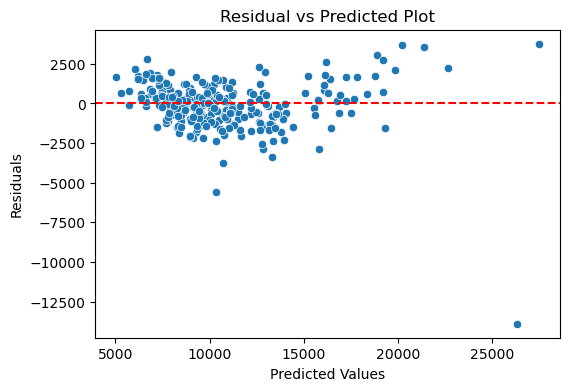

In [22]:
# Calculate residuals

residuals = y_test - y_pred

# Residual Plot

plt.figure(figsize=(6,4))

sns.scatterplot(x=y_pred, y=residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual vs Predicted Plot")

plt.show()

# Final Conclusion

- Multiple Linear Regression was used to predict car prices.
- EDA helped understand relationships between variables.
- Ridge and Lasso Regression improved model stability.
- The best model is selected based on the highest R2 Score.

# Interview Questions

## 1. What is Normalization and Standardization?

### Normalization
Normalization scales data between 0 and 1.

### Standardization
Standardization converts data into mean = 0 and standard deviation = 1.

### Benefits
- Improves model performance
- Removes scale differences
- Helps machine learning algorithms work better

# 2. Techniques to Handle Multicollinearity

1. Remove highly correlated variables
2. Use Ridge Regression
3. Use Lasso Regression
4. Use PCA
5. Check VIF values